**PRCP-1013: WalkRunClass**

**Walk vs Run activity Classification**

 **Table of contents:-**

1.Problem Statement

2.Import Required Libraries

3.Dataset Loading

4.Exploratory Data Analysis

5.Data Pre-Processing

6.Feature Scaling

7.Train-Test Split

8.Model Building

9.Model Training & Evaluation

10.Model Comparision Report

11.Classification Report

12.Challenges Faced

13.Techniques used


**PROBLEM STATEMENT**

1:-Prepare a complete data analysis report on the given data.

2:-Create a predictive model to classify whether a person is running or walking based on the given predictor variables.

3:-Create a report stating the performance of multiple models on this data and suggest the best model for production


**Dataset Desciption**

The dataset contains the recorded motion sensor readings of the users while executing daily activites.

Total columns:11

Total rows:88,588

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


**Dataset Loading**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv("/content/walkrun dataset.csv")

**Exploratory Data Analysis**

In [3]:
df.head()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,30-06-2017,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,30-06-2017,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,30-06-2017,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,30-06-2017,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,30-06-2017,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [4]:
df.describe()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,0.522170,0.500801,-0.074811,-0.562585,-0.313956,0.004160,0.037203,0.022327
std,0.499511,0.500002,1.009299,0.658458,0.486815,1.253423,1.198725,1.914423
min,0.000000,0.000000,-5.350500,-3.299000,-3.753800,-4.430600,-7.464700,-9.480000
25%,0.000000,0.000000,-0.381800,-1.033500,-0.376000,-0.920700,-0.644825,-1.345125
50%,1.000000,1.000000,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,1.000000,1.000000,0.355500,-0.241775,-0.085900,0.888800,0.733700,1.398200
max,1.000000,1.000000,5.603300,2.668000,1.640300,4.874200,8.498000,11.266200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [6]:
print("Missing_Values:\n",df.isnull().sum())
print("\nTotal_Duplicate_Values", df.duplicated().sum())

Missing_Values:
 date              0
time              0
username          0
wrist             0
activity          0
acceleration_x    0
acceleration_y    0
acceleration_z    0
gyro_x            0
gyro_y            0
gyro_z            0
dtype: int64

Total_Duplicate_Values 0


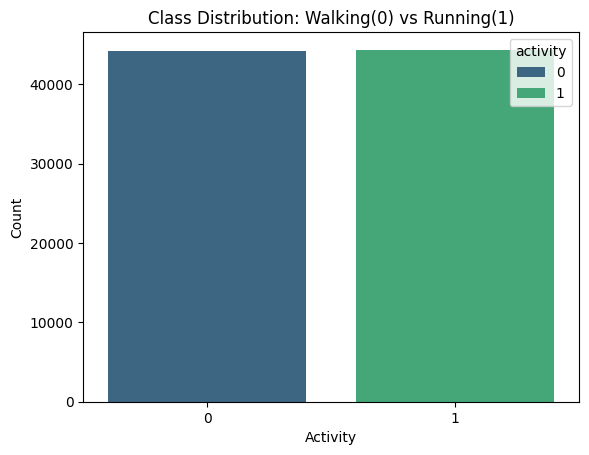

activity
1    44365
0    44223
Name: count, dtype: int64
activity
1    50.080146
0    49.919854
Name: proportion, dtype: float64


In [7]:
# identified Balanced classed using Countplot

sns.countplot(x='activity', data = df, hue='activity', palette= 'viridis')
plt.title('Class Distribution: Walking(0) vs Running(1)')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.show()
print(df['activity'].value_counts())
print(df['activity'].value_counts(normalize=True) * 100)



A countplot was used to verify class balance. The dataset showed near-perfect balance between Walking (44,223 samples) and Running (44,365 samples). This confirmed that no resampling or class weighting was required before model training.

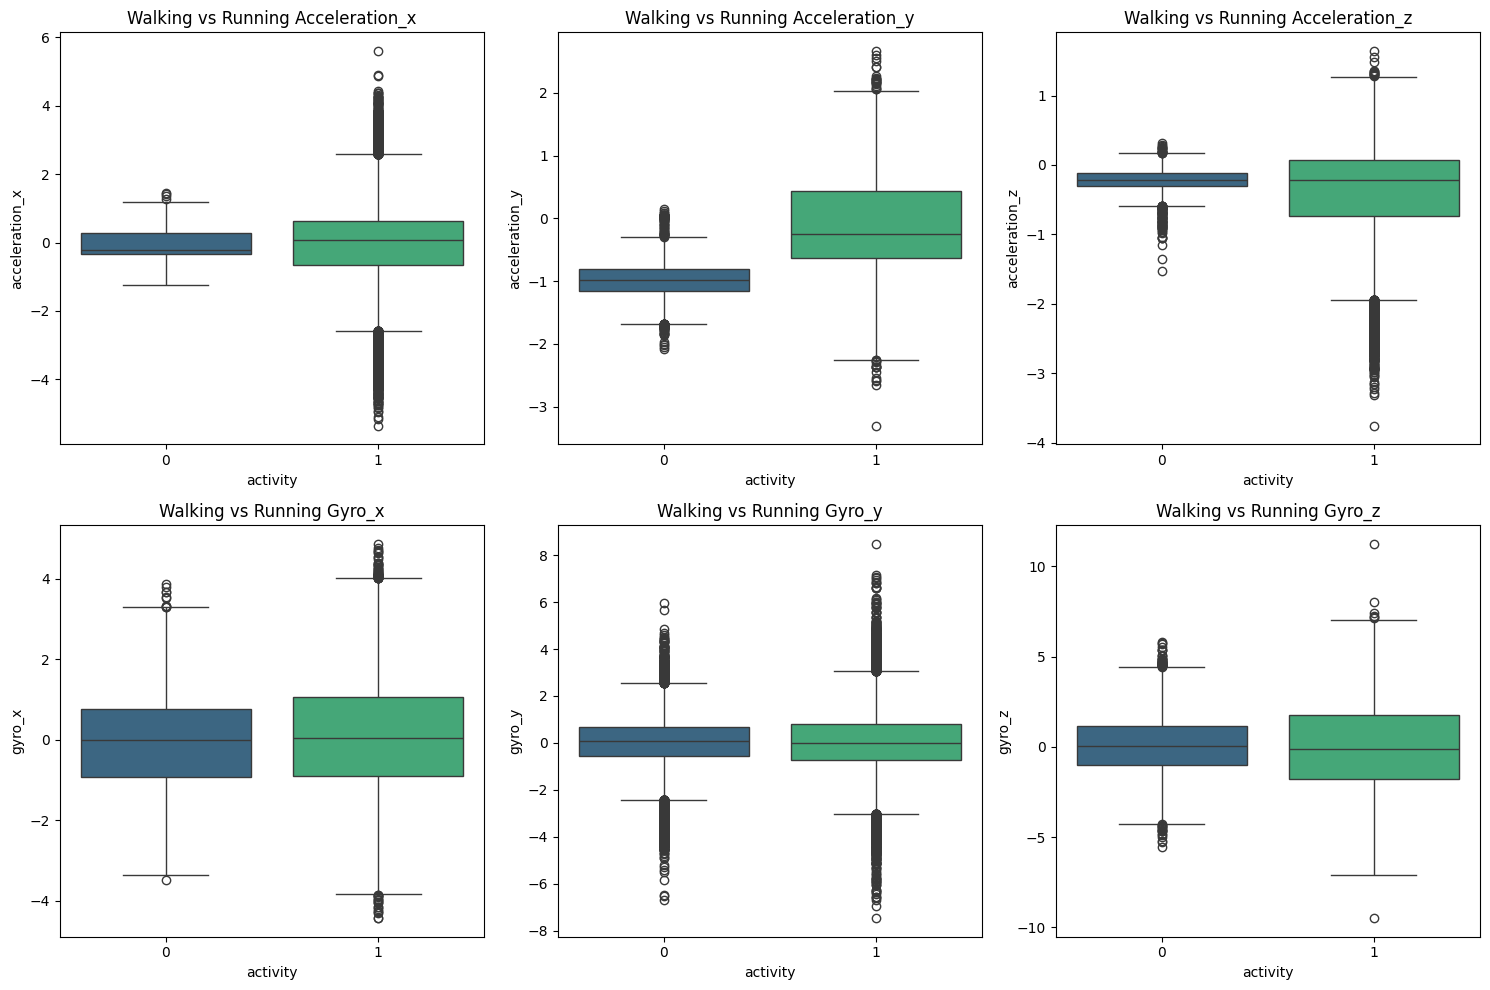

In [8]:
#  identified outliers

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15,10))

sns.boxplot(x='activity', y='acceleration_x', data=df, ax=axes[0,0], palette='viridis')
sns.boxplot(x='activity', y='acceleration_y', data=df, ax=axes[0,1], palette='viridis')
sns.boxplot(x='activity',y='acceleration_z', data=df, ax=axes[0,2], palette='viridis')
axes[0,0].set_title('Walking vs Running Acceleration_x')
axes[0,1].set_title('Walking vs Running Acceleration_y')
axes[0,2].set_title('Walking vs Running Acceleration_z')

sns.boxplot(x='activity', y='gyro_x',data = df, ax=axes[1,0], palette='viridis')
sns.boxplot(x='activity', y='gyro_y', data = df, ax= axes[1,1], palette='viridis')
sns.boxplot(x='activity', y='gyro_z', data = df, ax= axes[1,2], palette='viridis')
axes[1,0].set_title('Walking vs Running Gyro_x')
axes[1,1].set_title('Walking vs Running Gyro_y')
axes[1,2].set_title('Walking vs Running Gyro_z')

plt.tight_layout()
plt.show()

#plot showed Acceleration_y is the Strongest Separator and Gyro_x & Gyro_y are weakest features.
# Also displayed that running has more variation than walking.

Six boxplots (2x3 grid) were created for all sensor features grouped by activity. Key findings:

◆	Acceleration_y showed the strongest separation between Walking and Running — Walking median near -1, Running median near 0.

◆	All acceleration features showed stronger class separation than gyroscope features.

◆	Outliers were present in every feature, with Running showing more outliers due to the varied and dynamic nature of running movements.

◆	Gyro_x and Gyro_y showed significant overlap between classes, suggesting lower individual predictive power.


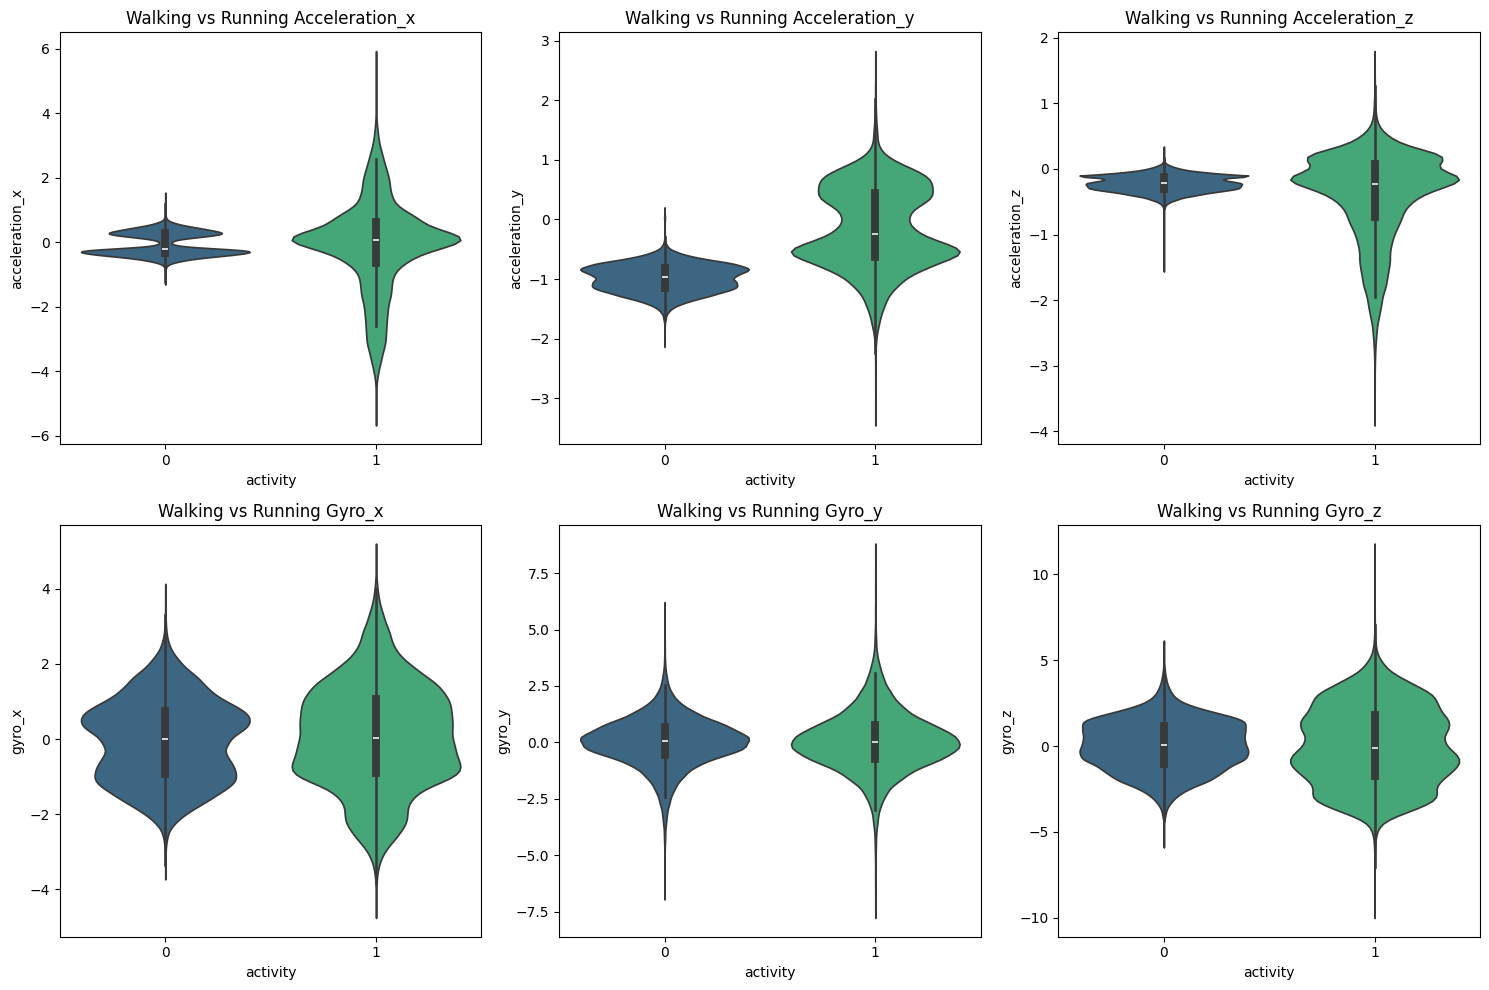

In [32]:
#Identified the distribution shape and density of the feature.
#Identifies how KDE smooths the distribution including Outliers into the Violin Shape.


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15,10))

sns.violinplot(x='activity', y='acceleration_x', data = df, ax=axes[0,0],palette= 'viridis')
sns.violinplot(x='activity', y='acceleration_y', data = df, ax=axes[0,1], palette= 'viridis')
sns.violinplot(x='activity', y='acceleration_z', data = df, ax=axes[0,2], palette= 'viridis')
axes[0,0].set_title('Walking vs Running Acceleration_x')
axes[0,1].set_title('Walking vs Running Acceleration_y')
axes[0,2].set_title('Walking vs Running Acceleration_z')

sns.violinplot(x='activity', y='gyro_x', data= df, ax = axes[1,0], palette= 'viridis')
sns.violinplot(x='activity', y='gyro_y', data= df, ax = axes[1,1], palette= 'viridis')
sns.violinplot(x='activity', y='gyro_z', data= df, ax = axes[1,2], palette = 'viridis')
axes[1,0].set_title('Walking vs Running Gyro_x')
axes[1,1].set_title('Walking vs Running Gyro_y')
axes[1,2].set_title('Walking vs Running Gyro_z')

plt.tight_layout()
plt.show()

#plot showed Acceleration_y is the Strongest Separator and Gyro_x & Gyro_y are weakest features.
# Also displayed that running has more variation than walking.

Violin plots confirmed boxplot findings while additionally revealing the density shape of each feature. Acceleration_y showed distinct bulge differences — Walking had a smaller, tighter bulge while Running had a wider, more spread distribution, confirming acceleration features carry more discriminative information than gyro features.

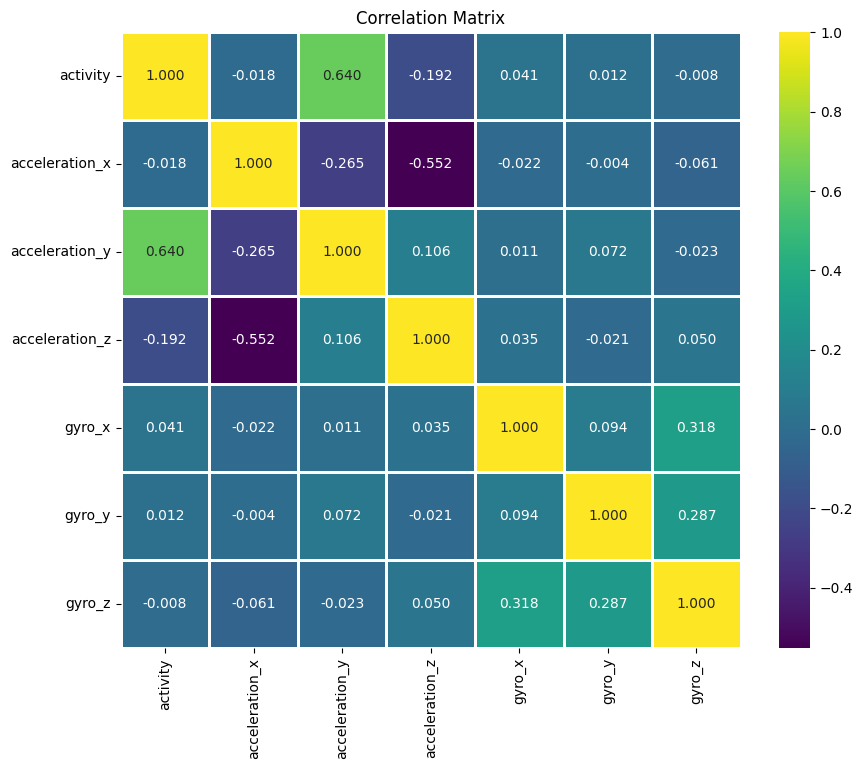

In [10]:
#identified the strongest predictor and multicollinearity.

corr = df[['activity','acceleration_x',	'acceleration_y',	'acceleration_z',	'gyro_x',	'gyro_y',	'gyro_z']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True , fmt = '.3f', cmap = 'viridis', linewidths = 2)
plt.title('Correlation Matrix')
plt.show()

#Strongest predictor is Acceleration_y.
#model does not have Multicollinearity which means featur brings unque information instead of any duplicacy.



A correlation heatmap was generated for all 6 sensor features plus the target variable. Key findings:

◆	Acceleration_y had the highest correlation with activity (0.640) — confirming it as the strongest individual predictor.

◆	No two features exceeded 0.7 correlation with each other — confirming the absence of multicollinearity.

◆	Each feature contributes independent information, justifying retention of all 6 sensor columns.


**Data Pre-Processing**

In [11]:
df = df.drop(columns=['date', 'time', 'username', 'wrist'])
df.size


620116

In [12]:
print(df.shape)
print(df.columns)

(88588, 7)
Index(['activity', 'acceleration_x', 'acceleration_y', 'acceleration_z',
       'gyro_x', 'gyro_y', 'gyro_z'],
      dtype='object')


In [13]:
df.head()

,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [14]:
X = df.drop('activity', axis = 1)
y = df['activity']
print(X.shape)
print(y.shape)
print(y.unique())

(88588, 6)
(88588,)
[0 1]


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 39, stratify = y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(62011, 6)
(26577, 6)
(62011,)
(26577,)


In [16]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train.shape)
print(X_test.shape)

(62011, 6)
(26577, 6)


*Step :	Action :	Reason*

1	Dropped: date, time, username, wrist :	No predictive value for activity classification

2	Separated X (features) and y (target) :	X = 6 sensor columns  |  y = activity column

3	Train-Test Split  (70:30, stratify=y) :	62,011 train rows  |  26,577 test rows  |  maintains class balance

4	RobustScaler on X_train only : Resistant to outliers via median & IQR  |  prevents data leakage


RobustScaler was chosen over StandardScaler because the dataset contains outliers confirmed during EDA. RobustScaler uses median and IQR instead of mean and standard deviation, making it resistant to extreme values. The scaler was fitted on X_train only and applied via transform to X_test to prevent data leakage.

**Model Creation**

              precision    recall  f1-score   support

           0       0.82      0.89      0.86     13267
           1       0.88      0.81      0.84     13310

    accuracy                           0.85     26577
   macro avg       0.85      0.85      0.85     26577
weighted avg       0.85      0.85      0.85     26577

Accuracy: 0.8507355984497874


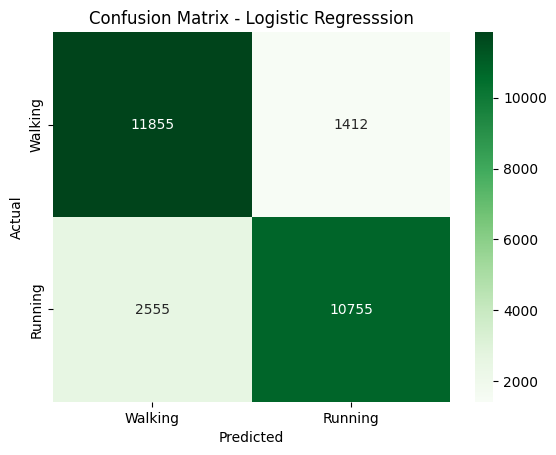

In [17]:
logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(X_train, y_train)
y_predict =logistic_regression_model.predict(X_test)
print(classification_report(y_test, y_predict))
print("Accuracy:",accuracy_score(y_test, y_predict))

sns.heatmap(confusion_matrix(y_test, y_predict),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['Walking', 'Running'],
            yticklabels=['Walking', 'Running']
            )
plt.title('Confusion Matrix - Logistic Regresssion')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



              precision    recall  f1-score   support

           0       0.99      0.99      0.99     13267
           1       0.99      0.99      0.99     13310

    accuracy                           0.99     26577
   macro avg       0.99      0.99      0.99     26577
weighted avg       0.99      0.99      0.99     26577

Accuracy: 0.9901794784964443


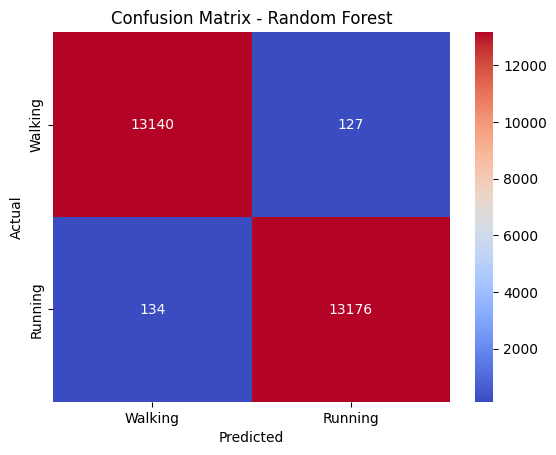

In [18]:
random_forest_model = RandomForestClassifier()
random_forest_model.fit(X_train, y_train)
y_predict = random_forest_model.predict(X_test)
print(classification_report(y_test, y_predict))
print("Accuracy:", accuracy_score(y_test, y_predict))

sns.heatmap(confusion_matrix(y_test, y_predict),
            annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Walking', 'Running'],
            yticklabels=['Walking','Running']
            )
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


              precision    recall  f1-score   support

           0       0.98      0.99      0.99     13267
           1       0.99      0.98      0.99     13310

    accuracy                           0.99     26577
   macro avg       0.99      0.99      0.99     26577
weighted avg       0.99      0.99      0.99     26577

Accuracy: 0.9857395492343003


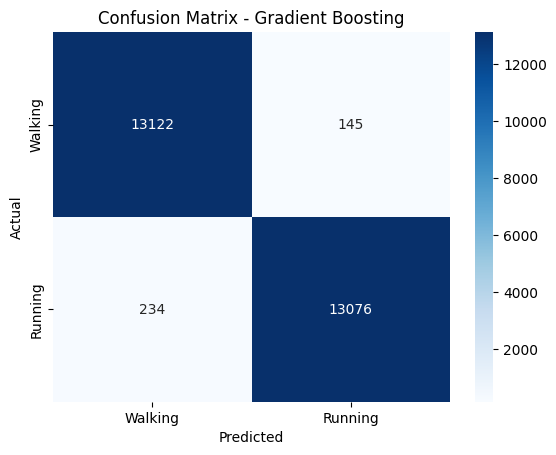

In [19]:
gradient_boosting_model = GradientBoostingClassifier()
gradient_boosting_model.fit(X_train, y_train)
y_predict = gradient_boosting_model.predict(X_test)
print(classification_report(y_test, y_predict))
print("Accuracy:", accuracy_score(y_test, y_predict))

sns.heatmap(confusion_matrix(y_test, y_predict),
            annot=True, fmt='d', cmap='Blues',
            xticklabels= ['Walking','Running'],
            yticklabels= ['Walking', 'Running']
            )
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     13267
           1       1.00      0.99      0.99     13310

    accuracy                           0.99     26577
   macro avg       0.99      0.99      0.99     26577
weighted avg       0.99      0.99      0.99     26577

Accuracy: 0.9905181171689807


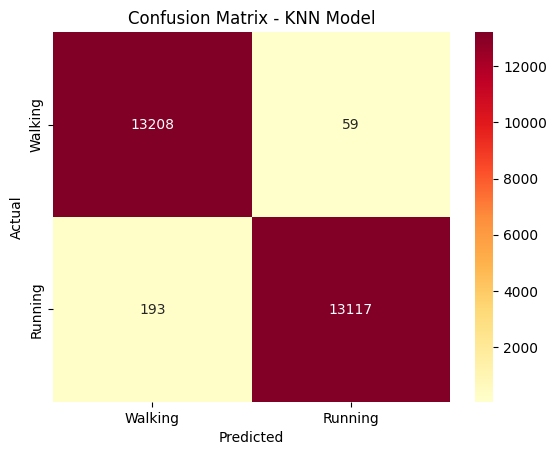

In [20]:
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train, y_train)
y_predict =KNN_model.predict(X_test)
print(classification_report(y_test, y_predict))
print("Accuracy:", accuracy_score(y_test, y_predict))

sns.heatmap(confusion_matrix(y_test, y_predict),
            annot = True, fmt = 'd', cmap='YlOrRd',
            xticklabels=['Walking','Running'],
            yticklabels= ['Walking','Running']
            )
plt.title('Confusion Matrix - KNN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



              precision    recall  f1-score   support

           0       0.99      0.99      0.99     13267
           1       0.99      0.99      0.99     13310

    accuracy                           0.99     26577
   macro avg       0.99      0.99      0.99     26577
weighted avg       0.99      0.99      0.99     26577

Accuracy: 0.9923241900891748


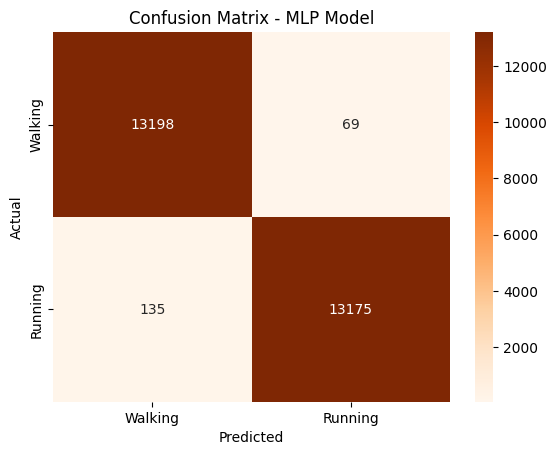

In [23]:
MLP_model = MLPClassifier()
MLP_model.fit(X_train, y_train)
y_predict = MLP_model.predict(X_test)
print(classification_report(y_test, y_predict))
print("Accuracy:", accuracy_score(y_test, y_predict))

sns.heatmap(confusion_matrix(y_test, y_predict),
      annot=True, fmt= 'd', cmap= 'Oranges',
      xticklabels= ['Walking', 'Running'],
      yticklabels= ['Walking', 'Running']
      )
plt.title('Confusion Matrix - MLP Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

*Individual Model Analysis*

Logistic Regression — 85.07% Test Accuracy
The baseline linear model. The relatively lower accuracy indicates that the relationship between sensor readings and activity is non-linear. Showed no overfitting with a gap of only 0.0029.

Random Forest — 99.02% Test Accuracy
Achieved perfect training accuracy (100%), raising a slight overfitting concern. The 14% accuracy jump over Logistic Regression confirms the non-linear nature of sensor data. Despite 100% train accuracy, 99.02% on completely unseen data demonstrates strong generalisation.

Gradient Boosting — 98.57% Test Accuracy
Despite building trees sequentially to correct errors at each step, GB did not surpass Random Forest. RF already achieved near-perfect accuracy, leaving minimal error for boosting to correct. Excellent stability with gap of 0.0007.

KNN Classifier — 99.05% Test Accuracy
Surprisingly competitive performance, slightly outperforming Random Forest on test data. KNN has no training phase — it memorises the entire training set and computes distances at prediction time, making it the slowest model at prediction despite fast training.


**Model Evaluation**

In [24]:
models ={
    'Logistic Regression' : logistic_regression_model,
    'Random Forest' : random_forest_model,
    'Gradient Boosting' : gradient_boosting_model,
    'KNN' : KNN_model,
    'MLP' : MLP_model
}

for name, model in models.items():
  train_accuracy = accuracy_score(y_train, model.predict(X_train))
  test_accuracy = accuracy_score(y_test, model.predict(X_test))
  print(f"{name}")
  print(f" Train: {train_accuracy : .4f} | Test : {test_accuracy: .4f} | Gap: {abs(train_accuracy - test_accuracy): .4f}")

Logistic Regression
 Train:  0.8536 | Test :  0.8507 | Gap:  0.0029
Random Forest
 Train:  1.0000 | Test :  0.9902 | Gap:  0.0098
Gradient Boosting
 Train:  0.9850 | Test :  0.9857 | Gap:  0.0007
KNN
 Train:  0.9921 | Test :  0.9905 | Gap:  0.0016
MLP
 Train:  0.9917 | Test :  0.9923 | Gap:  0.0006


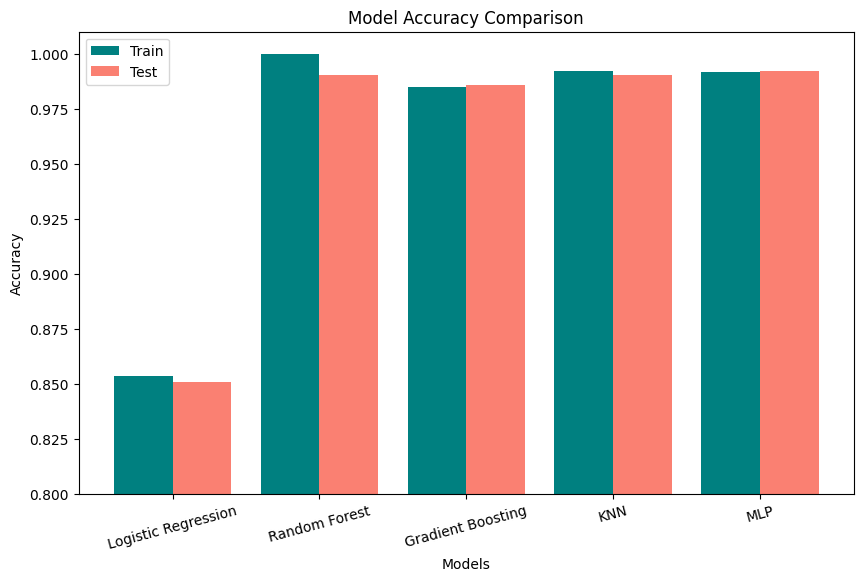

In [31]:
models_name = ['Logistic Regression', 'Random Forest',
               'Gradient Boosting', 'KNN', 'MLP']

train_scores = [0.8536, 1.0000, 0.9850, 0.9921, 0.9917]
test_scores  = [0.8507, 0.9902, 0.9857, 0.9905, 0.9923]

x = np.arange(len(models_name))
width = 0.4

plt.figure(figsize=(10,6))
plt.bar(x - width/2, train_scores, width, label= 'Train', color ='teal')
plt.bar(x + width/2, test_scores, width, label= 'Test', color = 'salmon')
plt.xticks(x, models_name, rotation = 15)
plt.ylim(0.8, 1.01)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.show()


MLP Classifier (Neural Network) — 99.23% Test Accuracy
The best performing model overall. Test accuracy (99.23%) exceeded training accuracy (99.17%) — the strongest indicator of genuine learning with zero overfitting. The smallest gap of 0.0006 across all models confirms the model learned real patterns rather than memorising training data.

The end goal of any predictive model is to correctly predict the target variable on unseen real-world data. MLP achieves this most effectively — combining the highest accuracy with the lowest overfitting risk across all evaluated models

**Hyperparameter Tuning**

In [28]:
param_grid = {
    'hidden_layer_sizes':[(100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'max_iter':[300, 500]
}

grid_search = GridSearchCV(
    estimator = MLPClassifier(),
    param_grid = param_grid,
    cv = 5,
    scoring = 'accuracy'
    )
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)


{'activation': 'relu', 'hidden_layer_sizes': (100, 50), 'max_iter': 500}
0.9909693571412663


GridSearchCV was applied to the MLP Classifier to find the optimal hyperparameter combination using cv=5 and scoring='accuracy'.
GridSearch Best Score: 99.09%  |  Original MLP Default Score: 99.23%
The tuned MLP (99.09%) performed slightly lower than the default MLP (99.23%). This occurred because GridSearchCV used cv=5 fold cross-validation, meaning each combination trained on a smaller subset of data. This confirms that default MLP parameters were already well-suited for this dataset — a strong validation of the model’s robustness.



**Challenges Faced & Techniques Used**


*Challenge :	Technique Used ->	Reason*

Outliers in all 6 sensor features :	Kept outliers — used RobustScaler ->	Real movement data includes genuine extreme values. Removing them would reduce real-world robustness.

Feature scaling with outliers present :	RobustScaler over StandardScaler -> RobustScaler uses median & IQR — resistant to outlier influence unlike StandardScaler's mean & std.

Risk of data leakage during scaling : Fit scaler on X_train only ->	Fitting on full data allows test distribution to influence scaling, giving falsely optimistic results.

Models achieving 99%+ — overfitting concern :	Compared train vs test accuracy gap ->	Gap < 0.01 confirms genuine learning rather than memorisation of training data.

Random Forest achieving 100% train accuracy :	Selected MLP over RF ->	RF's perfect train accuracy indicates memorisation. MLP's 99.17% train accuracy is more realistic.

GridSearchCV running too long :	Reduced param_grid and cv folds ->	Balancing thoroughness with computational feasibility on 88,588 rows of data.

Gyro features showing weak correlation : Retained all features -> Low individual correlation does not mean low combined predictive value — let the model decide.




**Conclusion**

This project successfully built a binary classification system to distinguish Walking from Running using wrist-worn sensor data. Key takeaways:
◆	The dataset was well-balanced, clean, and required no resampling or null value treatment.
◆	EDA revealed acceleration_y as the strongest individual predictor (correlation 0.640 with activity), while all features contribute independent information confirmed by absence of multicollinearity.
◆	The non-linear nature of sensor data was confirmed by the 14% accuracy gap between Logistic Regression (85%) and tree/neural network based models (99%).
◆	MLP Classifier was selected as the best model — 99.23% test accuracy, 0.0006 train-test gap, and test accuracy exceeding training accuracy — the strongest evidence of genuine learning and real-world readiness.
◆	Hyperparameter tuning confirmed that default MLP parameters were already optimal for this dataset, with GridSearch best score of 99.09%.


The model demonstrates strong potential for real-world deployment in fitness tracking applications, wearable devices, and health monitoring systems where accurate activity classification from wrist sensor data is required.